# Polynomial Regression — Complete Guide

This notebook covers **Polynomial Regression** and **Pipelines in Polynomial Regression** — with worked examples, real datasets, and rich visualizations using `matplotlib`, `seaborn`, `numpy`, and `sklearn`.

## Table of Contents
1. Why Polynomial Regression? — When linear fails
2. The Polynomial Regression Equation
3. Polynomial as "Linear Regression in Disguise"
4. Fitting Polynomial Regression from Scratch (OLS)
5. Choosing the Right Degree — Underfit vs Overfit
6. Polynomial Regression with sklearn (PolynomialFeatures)
7. **Pipelines — Why Use Them?**
8. **Building a Polynomial Regression Pipeline**
9. **Comparing Multiple Degrees with Pipelines + Cross-Validation**
10. **End-to-End Example — Salary Prediction Based on Position Level**
11. Multivariate Polynomial Regression
12. Regularized Polynomial Regression (Ridge Pipeline)

## Setup — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

np.random.seed(42)

## 1. Why Polynomial Regression?

**Simple/Multiple Linear Regression** assumes the relationship between X and Y is a **straight line/plane**. But many real-world relationships are **curved**:

| X | Y | Shape |
|---|---|---|
| Time | Rocket trajectory | Parabola |
| Age | Blood pressure | S-curve |
| Ad spend | Sales (diminishing returns) | Log-like curve |
| Position level | Salary in a company | Steeply exponential |
| Temperature | Reaction rate | Non-linear peak |

If we force a straight line through curved data, we get **high bias (underfitting)**. Polynomial regression lets us fit **curves** while still using the same linear regression machinery.

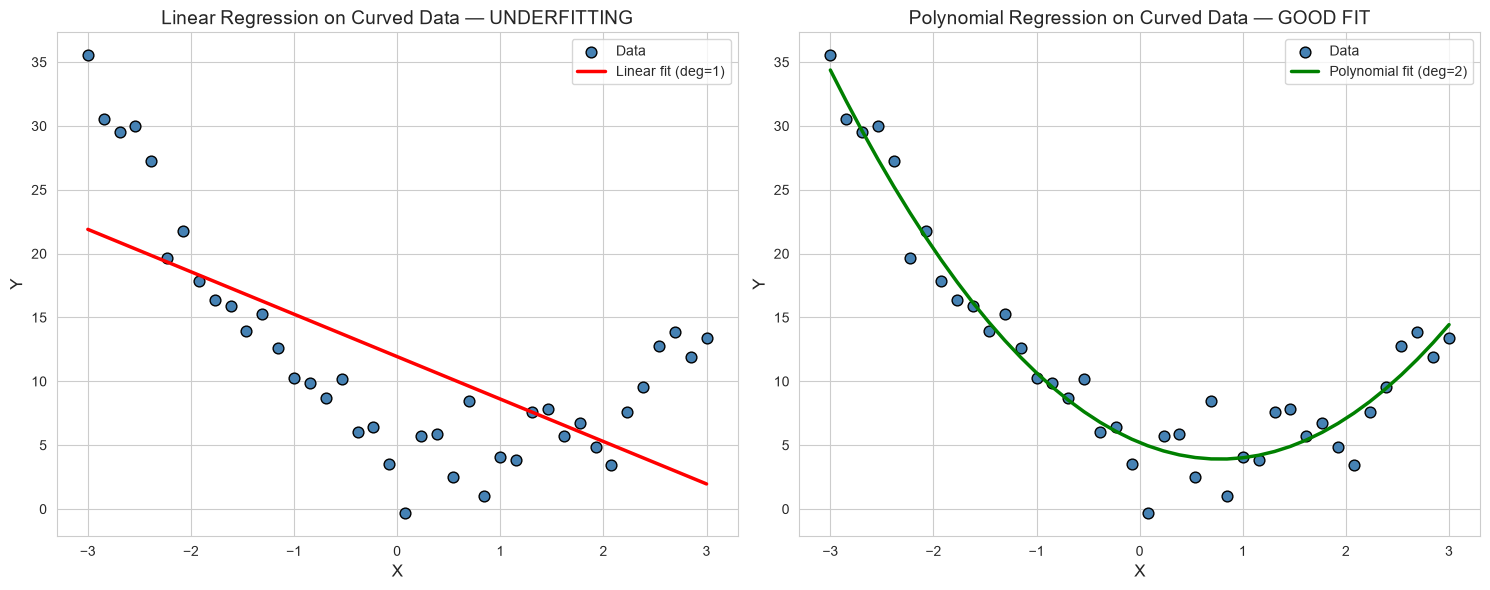

Linear R²      = 0.4640   (poor)
Polynomial R² = 0.9459   (excellent)


In [2]:
# Demo: linear regression FAILS on curved data
np.random.seed(0)
X_curve = np.linspace(-3, 3, 40)
y_curve = 2 * X_curve**2 - 3 * X_curve + 5 + np.random.normal(0, 2, 40)

# Fit a linear model
slope, intercept = np.polyfit(X_curve, y_curve, 1)
y_linear = intercept + slope * X_curve

# Fit a polynomial (degree 2)
coefs = np.polyfit(X_curve, y_curve, 2)
y_poly = np.polyval(coefs, X_curve)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_curve, y_curve, s=60, color='steelblue', edgecolor='black', label='Data')
axes[0].plot(X_curve, y_linear, 'r-', linewidth=2.5, label='Linear fit (deg=1)')
axes[0].set_title('Linear Regression on Curved Data — UNDERFITTING')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()

axes[1].scatter(X_curve, y_curve, s=60, color='steelblue', edgecolor='black', label='Data')
axes[1].plot(X_curve, y_poly, 'g-', linewidth=2.5, label='Polynomial fit (deg=2)')
axes[1].set_title('Polynomial Regression on Curved Data — GOOD FIT')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()

plt.tight_layout()
plt.show()

r2_linear = 1 - np.sum((y_curve - y_linear)**2) / np.sum((y_curve - y_curve.mean())**2)
r2_poly = 1 - np.sum((y_curve - y_poly)**2) / np.sum((y_curve - y_curve.mean())**2)
print(f'Linear R²      = {r2_linear:.4f}   (poor)')
print(f'Polynomial R² = {r2_poly:.4f}   (excellent)')

## 2. The Polynomial Regression Equation

For a single feature $x$, a polynomial of **degree d** is:

$$\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \dots + \theta_d x^d$$

| Degree | Equation | Shape |
|---|---|---|
| 1 | $\theta_0 + \theta_1 x$ | Straight line |
| 2 | $\theta_0 + \theta_1 x + \theta_2 x^2$ | Parabola (U or ∩) |
| 3 | $\theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3$ | S-shape / cubic |
| 4+ | Higher-order polynomials | Wavier curves |

**Note:** Even though the equation is *non-linear in x*, it is **linear in the coefficients (θ)** — that's why we can still use linear regression methods!

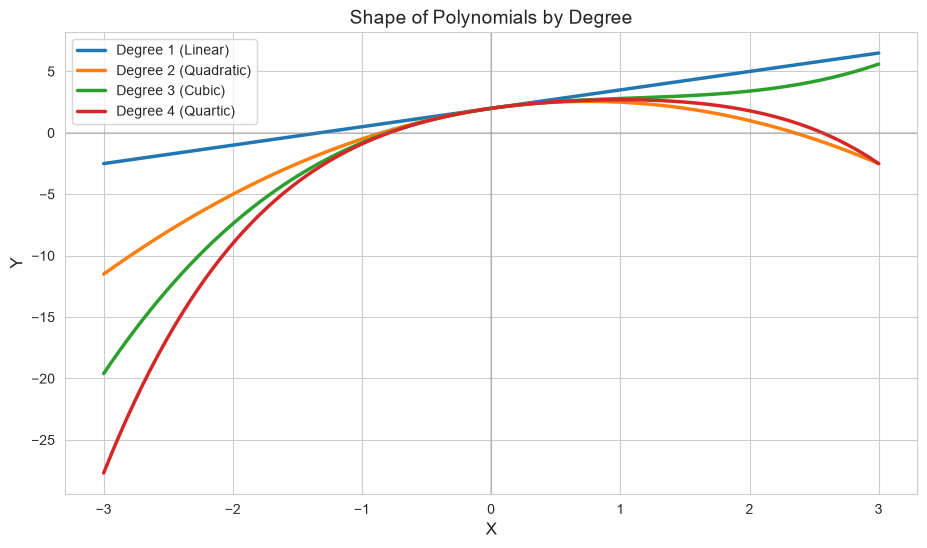

In [3]:
# Visualize different polynomial degrees
x_vis = np.linspace(-3, 3, 200)

curves = {
    'Degree 1 (Linear)':    2 + 1.5 * x_vis,
    'Degree 2 (Quadratic)': 2 + 1.5 * x_vis - x_vis**2,
    'Degree 3 (Cubic)':     2 + 1.5 * x_vis - x_vis**2 + 0.3 * x_vis**3,
    'Degree 4 (Quartic)':   2 + 1.5 * x_vis - x_vis**2 + 0.3 * x_vis**3 - 0.1 * x_vis**4
}

plt.figure(figsize=(11, 6))
for label, y_c in curves.items():
    plt.plot(x_vis, y_c, linewidth=2.5, label=label)
plt.title('Shape of Polynomials by Degree')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axhline(0, color='gray', alpha=0.3)
plt.axvline(0, color='gray', alpha=0.3)
plt.show()

## 3. Polynomial as "Linear Regression in Disguise"

**Key insight:** Polynomial regression is just **multiple linear regression** where we treat $x, x^2, x^3, \ldots$ as **separate features**.

Given one feature x, we build a **feature matrix**:

$$
\mathbf{X}_{\text{poly}} = \begin{bmatrix}
1 & x_1 & x_1^2 & x_1^3 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & x_2^3 & \cdots & x_2^d \\
\vdots & & & & & \vdots \\
1 & x_m & x_m^2 & x_m^3 & \cdots & x_m^d
\end{bmatrix}
$$

Then we solve it just like multiple linear regression:

$$\boldsymbol{\theta} = (\mathbf{X}_{\text{poly}}^T \mathbf{X}_{\text{poly}})^{-1} \mathbf{X}_{\text{poly}}^T \mathbf{y}$$

In [4]:
# Build a polynomial feature matrix by hand
x_small = np.array([1, 2, 3, 4, 5])

degree = 3
X_poly_manual = np.column_stack([x_small ** d for d in range(degree + 1)])

df_poly = pd.DataFrame(X_poly_manual, columns=[f'x^{d}' for d in range(degree + 1)])
print(f'Polynomial feature matrix (degree {degree}) for x = {list(x_small)}:\n')
print(df_poly.to_string(index=False))
print(f'\nShape: {X_poly_manual.shape}   (5 rows × 4 columns for degree 3 + 1 bias)')

Polynomial feature matrix (degree 3) for x = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]:

 x^0  x^1  x^2  x^3
   1    1    1    1
   1    2    4    8
   1    3    9   27
   1    4   16   64
   1    5   25  125

Shape: (5, 4)   (5 rows × 4 columns for degree 3 + 1 bias)


## 4. Fitting Polynomial Regression from Scratch (OLS)

Since it reduces to linear regression, we use the same **Normal Equation**:

$$\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

=== Fitted Polynomial (Degree 2) ===
θ₀ (intercept) = 5.2016
θ₁ (x)         = -3.3232
θ₂ (x²)        = 2.1343

Equation: ŷ = 5.20 + -3.32x + 2.13x²

True function used to generate data: y = 5 + (-3)x + 2x²
Our OLS solution recovered these coefficients accurately.


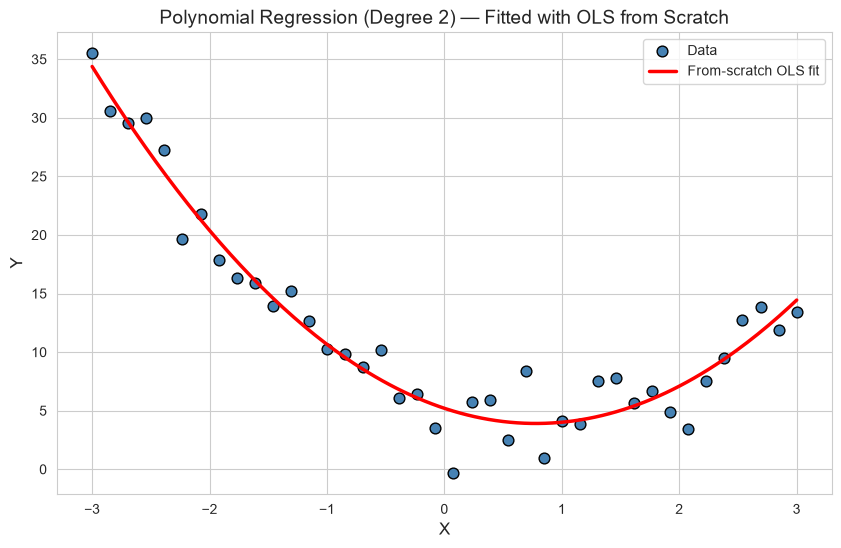

In [5]:
def polynomial_features_manual(x, degree):
    return np.column_stack([x ** d for d in range(degree + 1)])

def ols_fit(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

# Fit a degree-2 polynomial to our curved data from Section 1
X_poly = polynomial_features_manual(X_curve, degree=2)
theta_poly = ols_fit(X_poly, y_curve)

print('=== Fitted Polynomial (Degree 2) ===')
print(f'θ₀ (intercept) = {theta_poly[0]:.4f}')
print(f'θ₁ (x)         = {theta_poly[1]:.4f}')
print(f'θ₂ (x²)        = {theta_poly[2]:.4f}')
print(f'\nEquation: ŷ = {theta_poly[0]:.2f} + {theta_poly[1]:.2f}x + {theta_poly[2]:.2f}x²')
print(f'\nTrue function used to generate data: y = 5 + (-3)x + 2x²')
print('Our OLS solution recovered these coefficients accurately.')

# Predict and plot
x_plot = np.linspace(X_curve.min(), X_curve.max(), 200)
X_plot_poly = polynomial_features_manual(x_plot, degree=2)
y_plot_pred = X_plot_poly @ theta_poly

plt.figure(figsize=(10, 6))
plt.scatter(X_curve, y_curve, s=60, color='steelblue', edgecolor='black', label='Data')
plt.plot(x_plot, y_plot_pred, 'r-', linewidth=2.5, label=f'From-scratch OLS fit')
plt.title('Polynomial Regression (Degree 2) — Fitted with OLS from Scratch')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 5. Choosing the Right Degree — Underfit vs Overfit

The **degree** is the key hyperparameter for polynomial regression:

- **Too low** → underfitting (misses the pattern)
- **Too high** → overfitting (wiggles to hit every noisy point)
- **Just right** → captures the true curve

This is exactly the **bias-variance tradeoff** we saw before, but here we have direct control over model complexity through the degree parameter.

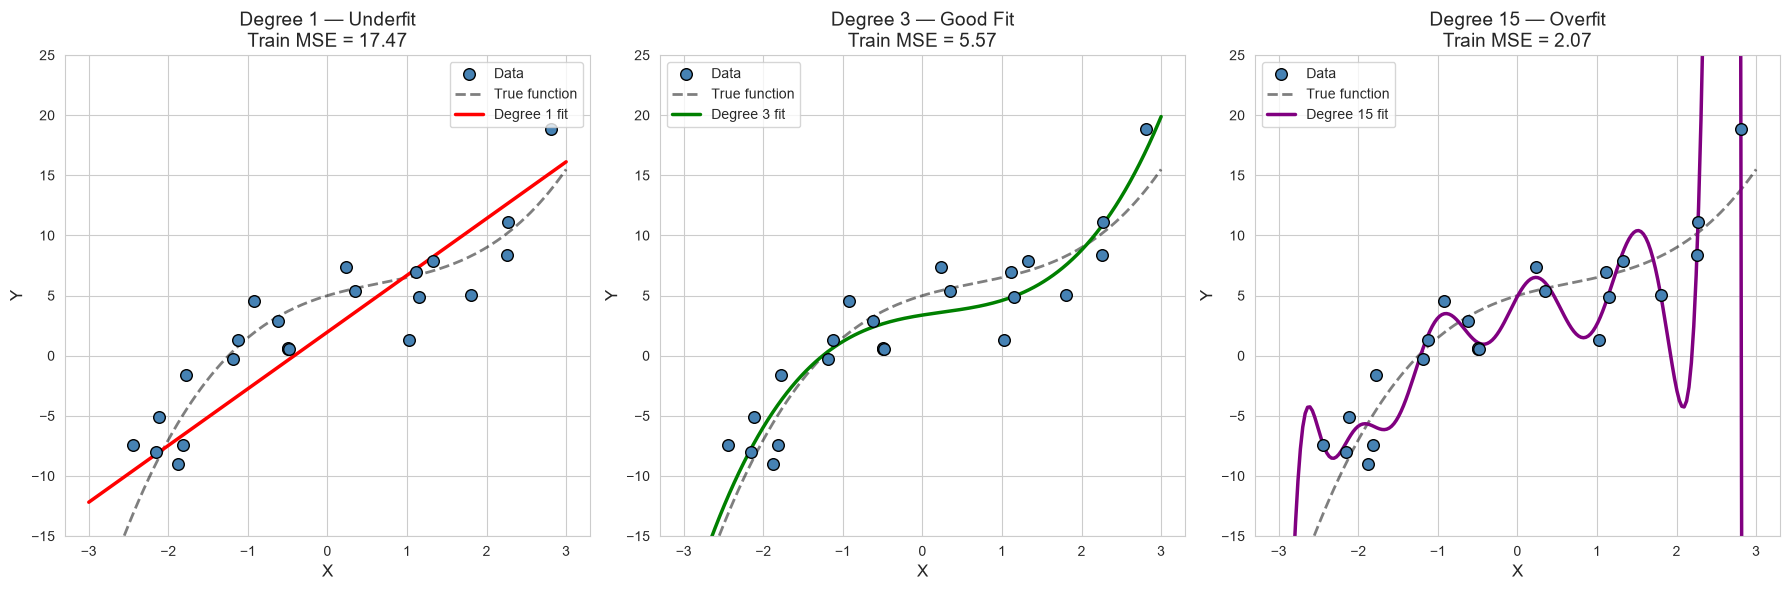

In [6]:
# Fit polynomials of different degrees
np.random.seed(1)
X_o = np.sort(np.random.uniform(-3, 3, 25))
y_true_o = 0.5 * X_o**3 - X_o**2 + 2 * X_o + 5
y_o = y_true_o + np.random.normal(0, 3, len(X_o))

x_plot = np.linspace(-3, 3, 200)
y_true_plot = 0.5 * x_plot**3 - x_plot**2 + 2 * x_plot + 5

degrees = [1, 3, 15]
titles = ['Degree 1 — Underfit', 'Degree 3 — Good Fit', 'Degree 15 — Overfit']
colors_fit = ['red', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, deg, title, col in zip(axes, degrees, titles, colors_fit):
    coef = np.polyfit(X_o, y_o, deg)
    y_plot_fit = np.polyval(coef, x_plot)
    y_train_fit = np.polyval(coef, X_o)

    ax.scatter(X_o, y_o, s=70, color='steelblue', edgecolor='black', label='Data', zorder=3)
    ax.plot(x_plot, y_true_plot, 'k--', linewidth=2, alpha=0.5, label='True function')
    ax.plot(x_plot, y_plot_fit, color=col, linewidth=2.5, label=f'Degree {deg} fit')

    train_mse = np.mean((y_o - y_train_fit) ** 2)
    ax.set_title(f'{title}\nTrain MSE = {train_mse:.2f}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_ylim(-15, 25)
    ax.legend()

plt.tight_layout()
plt.show()

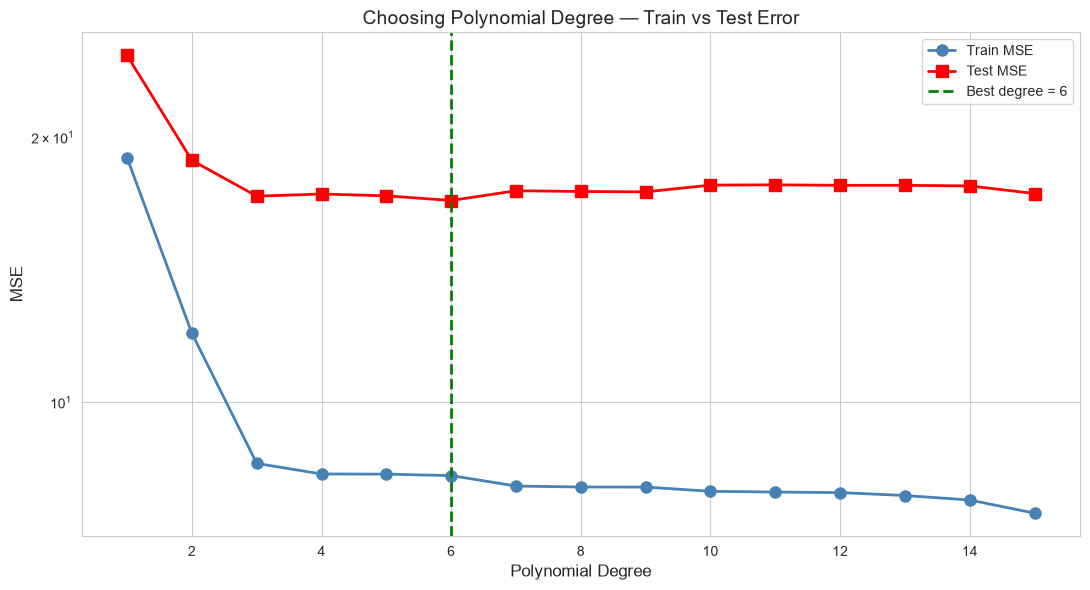

Best degree (lowest test MSE) = 6


In [7]:
# Train vs Test error across degrees — the classic U-shape
np.random.seed(2)
X_all = np.random.uniform(-3, 3, 100)
y_all = 0.5 * X_all**3 - X_all**2 + 2 * X_all + 5 + np.random.normal(0, 3, 100)

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.3, random_state=1)

degrees_range = range(1, 16)
train_errs, test_errs = [], []
for d in degrees_range:
    coef = np.polyfit(X_train, y_train, d)
    train_errs.append(np.mean((y_train - np.polyval(coef, X_train))**2))
    test_errs.append(np.mean((y_test - np.polyval(coef, X_test))**2))

best_deg = degrees_range[np.argmin(test_errs)]

plt.figure(figsize=(11, 6))
plt.plot(degrees_range, train_errs, 'o-', color='steelblue', linewidth=2, markersize=8, label='Train MSE')
plt.plot(degrees_range, test_errs, 's-', color='red', linewidth=2, markersize=8, label='Test MSE')
plt.axvline(x=best_deg, color='green', linestyle='--', linewidth=2, label=f'Best degree = {best_deg}')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Choosing Polynomial Degree — Train vs Test Error')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best degree (lowest test MSE) = {best_deg}')

## 6. Polynomial Regression with sklearn (PolynomialFeatures)

In practice, we use `sklearn.preprocessing.PolynomialFeatures` to build the polynomial feature matrix, then apply `LinearRegression` to it.

**Two steps:**
1. **`PolynomialFeatures(degree=d)`** transforms x → [1, x, x², ..., x^d]
2. **`LinearRegression()`** finds the best θ coefficients

In [8]:
# Manually running the two steps
X_train_2d = X_train.reshape(-1, 1)
X_test_2d = X_test.reshape(-1, 1)

# Step 1: transform features
poly_transformer = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly_transformer.fit_transform(X_train_2d)
X_test_poly = poly_transformer.transform(X_test_2d)

print('Original X_train shape:', X_train_2d.shape)
print('Transformed X_train shape:', X_train_poly.shape, ' (added x², x³ columns)')
print(f'\nFeature names: {poly_transformer.get_feature_names_out(["x"])}')

# Step 2: fit linear regression
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred_train = model.predict(X_train_poly)
y_pred_test = model.predict(X_test_poly)

print(f'\nIntercept: {model.intercept_:.4f}')
print(f'Coefficients: {model.coef_}')
print(f'\nTrain MSE = {mean_squared_error(y_train, y_pred_train):.4f}')
print(f'Test MSE  = {mean_squared_error(y_test, y_pred_test):.4f}')
print(f'Test R²   = {r2_score(y_test, y_pred_test):.4f}')

Original X_train shape: (70, 1)
Transformed X_train shape: (70, 3)  (added x², x³ columns)

Feature names: ['x' 'x^2' 'x^3']

Intercept: 4.6711
Coefficients: [ 2.62241452 -0.85559961  0.46653906]

Train MSE = 8.5201
Test MSE  = 17.1410
Test R²   = 0.7771


## 7. Pipelines — Why Use Them?

The two-step approach above has **problems**:

❌ You have to remember to apply the SAME transformation to train and test data separately  
❌ Easy to accidentally leak information (e.g., fit scaler on test)  
❌ Verbose — many intermediate variables (`X_train_poly`, `X_test_poly`, ...)  
❌ Hard to combine with cross-validation and grid search  

### What is a Pipeline?

A **Pipeline** is a wrapper that chains multiple steps together into a single object. It:

✅ **Automatically applies transformations** to train and test data in the correct order  
✅ **Prevents data leakage** by fitting on train only, then applying to test  
✅ **Cleaner code** — one `.fit()` call, one `.predict()` call  
✅ **Plays perfectly with cross-validation and GridSearchCV**  
✅ **Reusable** — save the pipeline, load it later, still works

### Visual Analogy — Factory Assembly Line

```
Raw data → [Poly Features] → [Scaler] → [Linear Regression] → Predictions
                                                                       
         └─────────────────── ONE Pipeline object ─────────────────────┘
```

When you call `pipeline.fit(X, y)`, sklearn:
1. Fits PolynomialFeatures on X, transforms it
2. Fits StandardScaler on the transformed data
3. Fits LinearRegression on the scaled data

When you call `pipeline.predict(new_X)`, sklearn:
1. Transforms new_X with the ALREADY-FITTED PolynomialFeatures
2. Scales it with the ALREADY-FITTED scaler
3. Predicts with the trained model

## 8. Building a Polynomial Regression Pipeline

Two syntaxes:

### Method 1: `Pipeline([...])` — explicit names
```python
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
```

### Method 2: `make_pipeline(...)` — auto-names steps
```python
pipe = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearRegression()
)
```

In [9]:
# Build the pipeline
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

print('Pipeline steps:')
for name, step in poly_pipe.steps:
    print(f'  → {name}: {step.__class__.__name__}')

# Fit and evaluate — just ONE .fit() and ONE .predict()
poly_pipe.fit(X_train_2d, y_train)

y_pred_train = poly_pipe.predict(X_train_2d)
y_pred_test = poly_pipe.predict(X_test_2d)

print(f'\n=== Pipeline Performance ===')
print(f'Train MSE = {mean_squared_error(y_train, y_pred_train):.4f}')
print(f'Test MSE  = {mean_squared_error(y_test, y_pred_test):.4f}')
print(f'Test R²   = {r2_score(y_test, y_pred_test):.4f}')

# Access internal steps
print(f'\nExtracted intercept: {poly_pipe.named_steps["model"].intercept_:.4f}')
print(f'Extracted coefficients: {poly_pipe.named_steps["model"].coef_}')

Pipeline steps:
  → poly: PolynomialFeatures
  → scaler: StandardScaler
  → model: LinearRegression

=== Pipeline Performance ===
Train MSE = 8.5201
Test MSE  = 17.1410
Test R²   = 0.7771

Extracted intercept: 1.3199
Extracted coefficients: [ 4.41278876 -2.4647285   4.95157841]


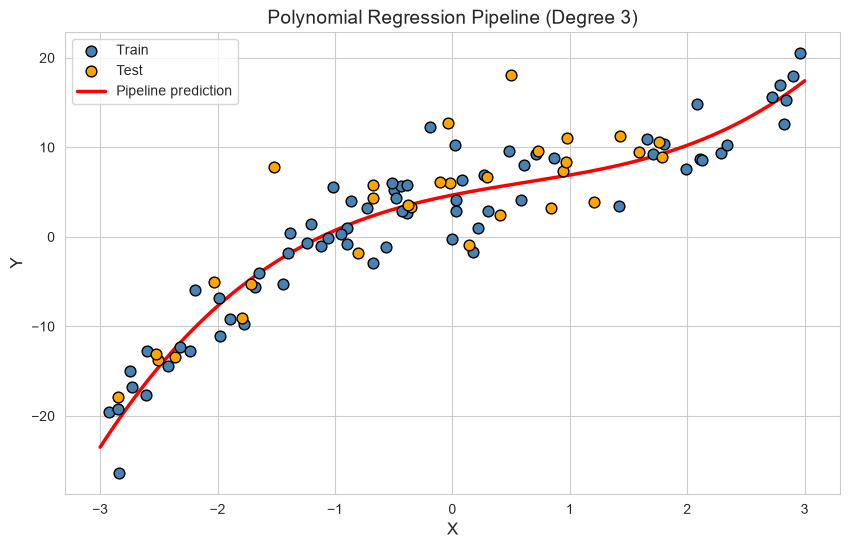

In [10]:
# Visualize the pipeline fit
x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_pipe_plot = poly_pipe.predict(x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, s=60, color='steelblue', edgecolor='black', label='Train', zorder=3)
plt.scatter(X_test, y_test, s=60, color='orange', edgecolor='black', label='Test', zorder=3)
plt.plot(x_plot, y_pipe_plot, 'r-', linewidth=2.5, label='Pipeline prediction')
plt.title('Polynomial Regression Pipeline (Degree 3)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 9. Comparing Multiple Degrees with Pipelines + Cross-Validation

**Cross-validation** = a robust way to estimate test performance without wasting data. K-fold CV:
1. Split data into K folds
2. Train on K−1 folds, test on the last fold
3. Repeat K times, average the scores

Combined with pipelines, we can cleanly compare polynomial degrees.

 Degree Mean CV MSE Std CV MSE
      1      21.089     ±4.032
      2      14.903     ±6.261
      3      12.000     ±3.698
      4      12.021     ±4.286
      5      12.417     ±4.078
      6      12.474     ±4.001
      7      12.484     ±3.843
      8      12.738     ±3.753
      9      12.833     ±3.612
     10      13.901     ±4.143
     11      14.091     ±4.139
     12      14.036     ±4.338

Best degree by cross-validation = 3


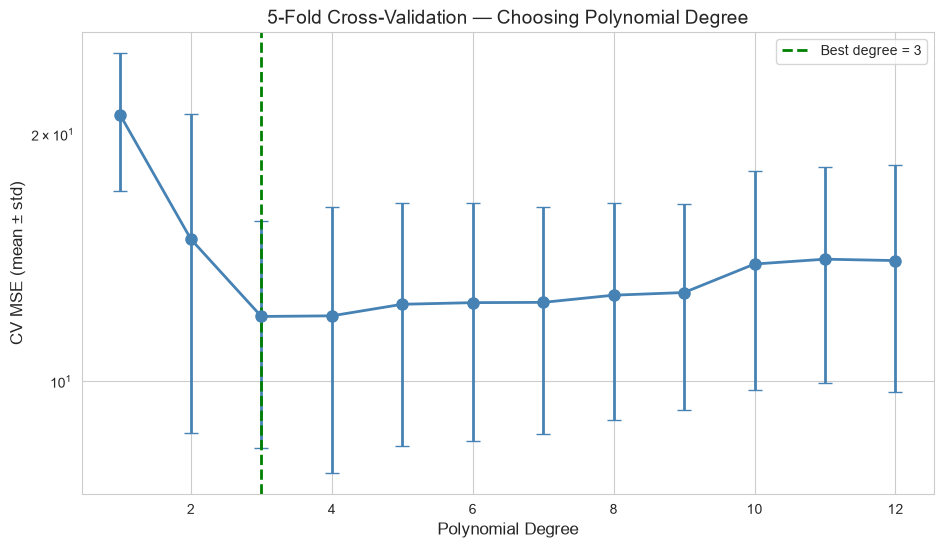

In [11]:
# Compare degrees 1–12 using 5-fold cross-validation
X_all_2d = X_all.reshape(-1, 1)

degrees_to_try = range(1, 13)
mean_scores = []
std_scores = []

for d in degrees_to_try:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    scores = cross_val_score(pipe, X_all_2d, y_all, cv=5, scoring='neg_mean_squared_error')
    mean_scores.append(-scores.mean())
    std_scores.append(scores.std())

df_cv = pd.DataFrame({
    'Degree': list(degrees_to_try),
    'Mean CV MSE': [f'{m:.3f}' for m in mean_scores],
    'Std CV MSE': [f'±{s:.3f}' for s in std_scores]
})
print(df_cv.to_string(index=False))

best_d = list(degrees_to_try)[np.argmin(mean_scores)]
print(f'\nBest degree by cross-validation = {best_d}')

plt.figure(figsize=(11, 6))
plt.errorbar(degrees_to_try, mean_scores, yerr=std_scores, marker='o', markersize=8,
             linewidth=2, capsize=5, color='steelblue')
plt.axvline(x=best_d, color='green', linestyle='--', linewidth=2, label=f'Best degree = {best_d}')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV MSE (mean ± std)')
plt.title('5-Fold Cross-Validation — Choosing Polynomial Degree')
plt.yscale('log')
plt.legend()
plt.show()

## 10. End-to-End Example — Salary Prediction Based on Position Level

A classic dataset: predict salary based on **position level** in a company. The relationship is highly non-linear — salaries grow exponentially at higher levels.

In [12]:
position_data = pd.DataFrame({
    'Position': ['Business Analyst', 'Junior Consultant', 'Senior Consultant', 'Manager',
                 'Country Manager', 'Region Manager', 'Partner', 'Senior Partner',
                 'C-level', 'CEO'],
    'Level': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary': [45000, 50000, 60000, 80000, 110000, 150000, 200000, 300000, 500000, 1000000]
})
print(position_data.to_string(index=False))

         Position  Level  Salary
 Business Analyst      1   45000
Junior Consultant      2   50000
Senior Consultant      3   60000
          Manager      4   80000
  Country Manager      5  110000
   Region Manager      6  150000
          Partner      7  200000
   Senior Partner      8  300000
          C-level      9  500000
              CEO     10 1000000


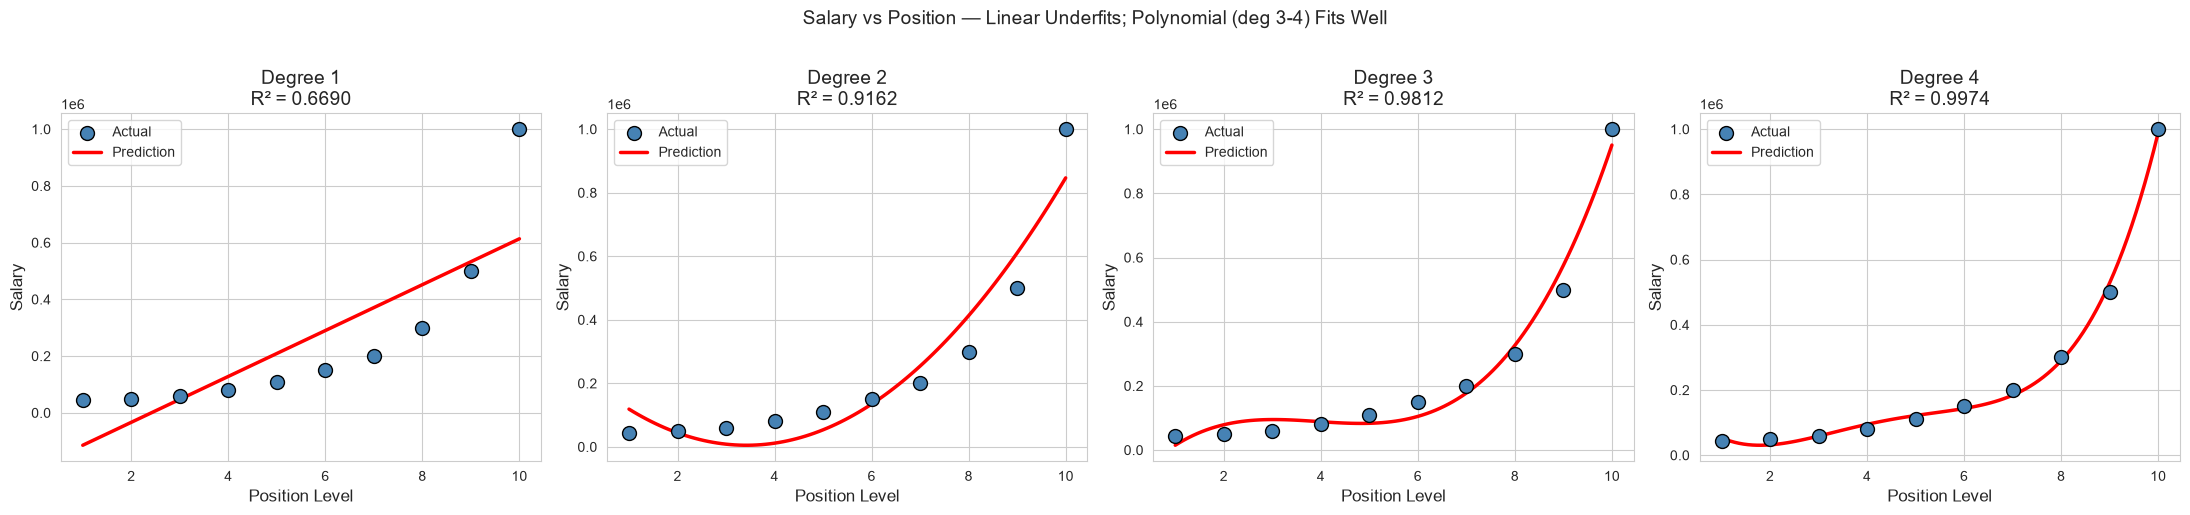

In [13]:
X_pos = position_data[['Level']].values
y_pos = position_data['Salary'].values

# Compare linear vs polynomial degree 2, 3, 4
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
x_plot = np.linspace(1, 10, 100).reshape(-1, 1)

for ax, deg in zip(axes, [1, 2, 3, 4]):
    pipe = make_pipeline(PolynomialFeatures(degree=deg, include_bias=False), LinearRegression())
    pipe.fit(X_pos, y_pos)
    y_line = pipe.predict(x_plot)
    r2 = r2_score(y_pos, pipe.predict(X_pos))

    ax.scatter(X_pos, y_pos, s=100, color='steelblue', edgecolor='black', label='Actual', zorder=3)
    ax.plot(x_plot, y_line, 'r-', linewidth=2.5, label='Prediction')
    ax.set_title(f'Degree {deg}\nR² = {r2:.4f}')
    ax.set_xlabel('Position Level')
    ax.set_ylabel('Salary')
    ax.legend()

plt.suptitle('Salary vs Position — Linear Underfits; Polynomial (deg 3-4) Fits Well',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Build a proper pipeline and predict for new levels
salary_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
salary_pipe.fit(X_pos, y_pos)

new_levels = np.array([[3.5], [6.5], [7.5], [8.5]])
predictions = salary_pipe.predict(new_levels)

print('=== Salary Predictions for In-Between Levels ===\n')
for lvl, pred in zip(new_levels.flatten(), predictions):
    print(f'  Level {lvl}: Predicted salary = ₹{pred:,.2f}')

print(f'\nFull-dataset R² = {r2_score(y_pos, salary_pipe.predict(X_pos)):.4f}')

=== Salary Predictions for In-Between Levels ===

  Level 3.5: Predicted salary = ₹77,125.13
  Level 6.5: Predicted salary = ₹158,862.45
  Level 7.5: Predicted salary = ₹225,126.29
  Level 8.5: Predicted salary = ₹387,705.69

Full-dataset R² = 0.9974


## 11. Multivariate Polynomial Regression

For multiple features, PolynomialFeatures generates **all cross-term combinations** up to the given degree.

For 2 features (x₁, x₂) and degree 2, we get:

$$1, x_1, x_2, x_1^2, x_1 x_2, x_2^2$$

The **cross-term** $x_1 x_2$ is called an **interaction term** — it captures how the effect of one feature depends on another.

In [15]:
# Demo: PolynomialFeatures on a small 2-feature example
X_two = np.array([[1, 2],
                   [3, 4],
                   [5, 6]])

poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly_two = poly.fit_transform(X_two)

print('Original features:')
print(pd.DataFrame(X_two, columns=['x1', 'x2']).to_string(index=False))

print(f'\nPolynomial degree-2 features ({X_poly_two.shape[1]} columns):')
print(pd.DataFrame(X_poly_two, columns=poly.get_feature_names_out(['x1', 'x2'])).to_string(index=False))

print('\nEach row now contains: [1, x1, x2, x1², x1·x2, x2²]')

Original features:
 x1  x2
  1   2
  3   4
  5   6

Polynomial degree-2 features (6 columns):
  1  x1  x2  x1^2  x1 x2  x2^2
1.0 1.0 2.0   1.0    2.0   4.0
1.0 3.0 4.0   9.0   12.0  16.0
1.0 5.0 6.0  25.0   30.0  36.0

Each row now contains: [1, x1, x2, x1², x1·x2, x2²]


C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


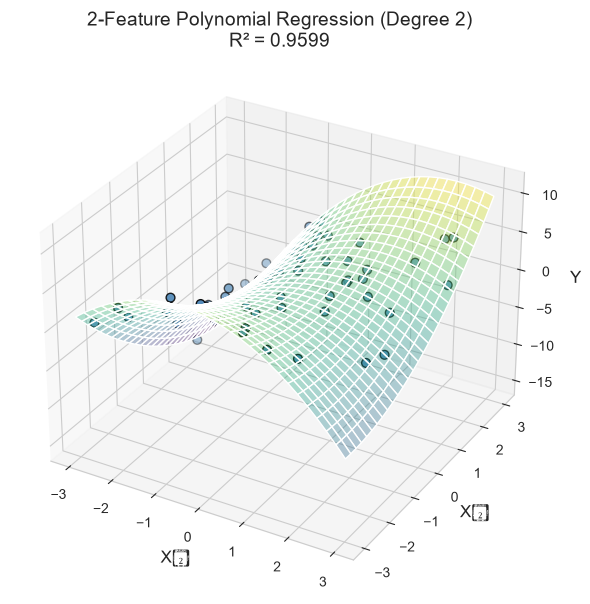

In [16]:
# 2-feature polynomial regression — visualize the fitted surface
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(3)
n = 60
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
y_multi = 2 + 1.5*x1 - x1**2 + 0.5*x2**2 + x1*x2 + np.random.normal(0, 1, n)

X_multi = np.column_stack([x1, x2])

pipe_multi = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
pipe_multi.fit(X_multi, y_multi)

# Build grid for surface plot
x1_grid, x2_grid = np.meshgrid(np.linspace(-3, 3, 30), np.linspace(-3, 3, 30))
X_grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])
y_grid_pred = pipe_multi.predict(X_grid).reshape(x1_grid.shape)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_multi, s=40, color='steelblue', edgecolor='black', label='Data')
ax.plot_surface(x1_grid, x2_grid, y_grid_pred, alpha=0.35, cmap='viridis')
ax.set_xlabel('X₁')
ax.set_ylabel('X₂')
ax.set_zlabel('Y')
ax.set_title(f'2-Feature Polynomial Regression (Degree 2)\nR² = {r2_score(y_multi, pipe_multi.predict(X_multi)):.4f}')
plt.show()

## 12. Regularized Polynomial Regression (Ridge Pipeline)

**Problem:** High-degree polynomials overfit badly.

**Solution:** Add **regularization** — a penalty on large coefficients.

**Ridge regression** adds an L2 penalty to the cost function:

$$J_{ridge}(\theta) = \underbrace{\frac{1}{2m}\sum(\hat{y} - y)^2}_{\text{MSE}} + \underbrace{\lambda \sum_{j=1}^n \theta_j^2}_{\text{penalty}}$$

- **λ (alpha in sklearn)** controls the strength of regularization
- λ = 0 → same as linear regression (no regularization)
- λ → ∞ → coefficients shrink toward 0
- Ridge lets us use **high-degree polynomials** without catastrophic overfitting

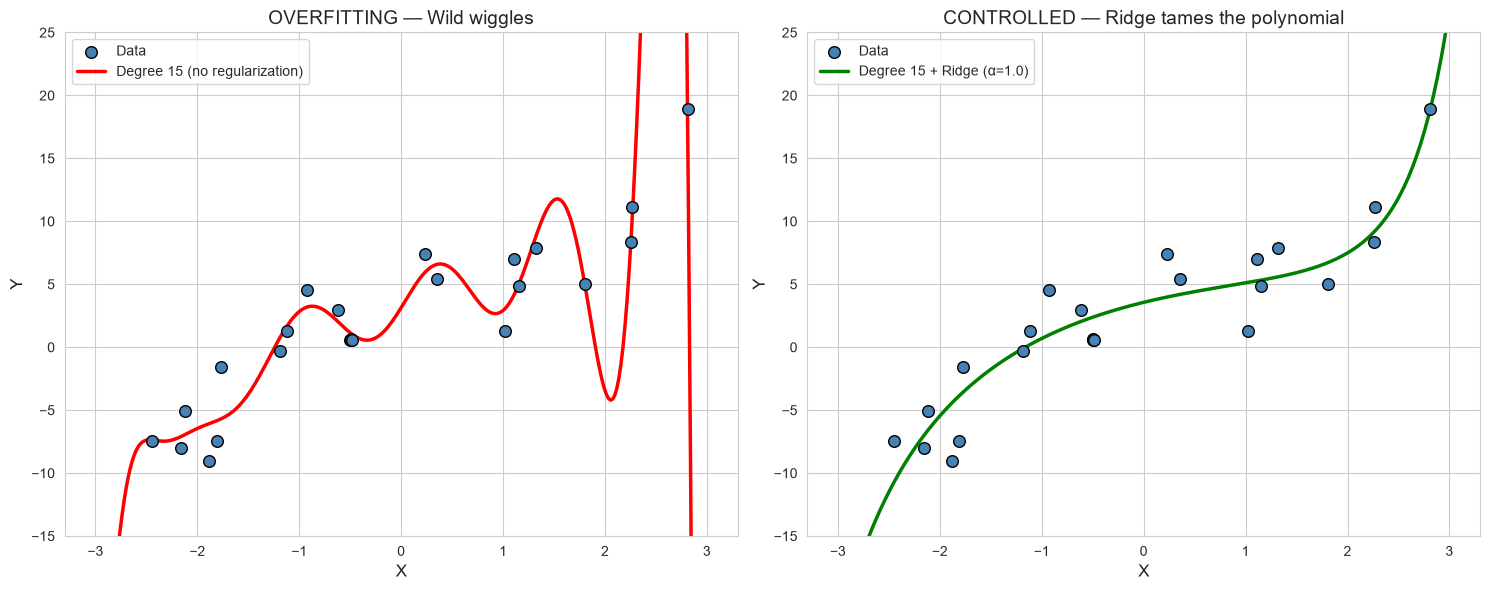

In [17]:
# Compare degree-15 polynomial WITHOUT and WITH ridge regularization
np.random.seed(1)
X_r = np.sort(np.random.uniform(-3, 3, 25))
y_r = 0.5 * X_r**3 - X_r**2 + 2*X_r + 5 + np.random.normal(0, 3, 25)

X_r_2d = X_r.reshape(-1, 1)
x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

# Pipeline 1: high-degree polynomial (no regularization)
pipe_no_reg = make_pipeline(
    PolynomialFeatures(degree=15, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
pipe_no_reg.fit(X_r_2d, y_r)

# Pipeline 2: high-degree polynomial with Ridge
pipe_ridge = make_pipeline(
    PolynomialFeatures(degree=15, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1.0)
)
pipe_ridge.fit(X_r_2d, y_r)

y_no_reg = pipe_no_reg.predict(x_plot)
y_ridge = pipe_ridge.predict(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_r, y_r, s=70, color='steelblue', edgecolor='black', label='Data', zorder=3)
axes[0].plot(x_plot, y_no_reg, 'r-', linewidth=2.5, label='Degree 15 (no regularization)')
axes[0].set_title('OVERFITTING — Wild wiggles')
axes[0].set_ylim(-15, 25)
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
axes[0].legend()

axes[1].scatter(X_r, y_r, s=70, color='steelblue', edgecolor='black', label='Data', zorder=3)
axes[1].plot(x_plot, y_ridge, 'g-', linewidth=2.5, label='Degree 15 + Ridge (α=1.0)')
axes[1].set_title('CONTROLLED — Ridge tames the polynomial')
axes[1].set_ylim(-15, 25)
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].legend()

plt.tight_layout()
plt.show()

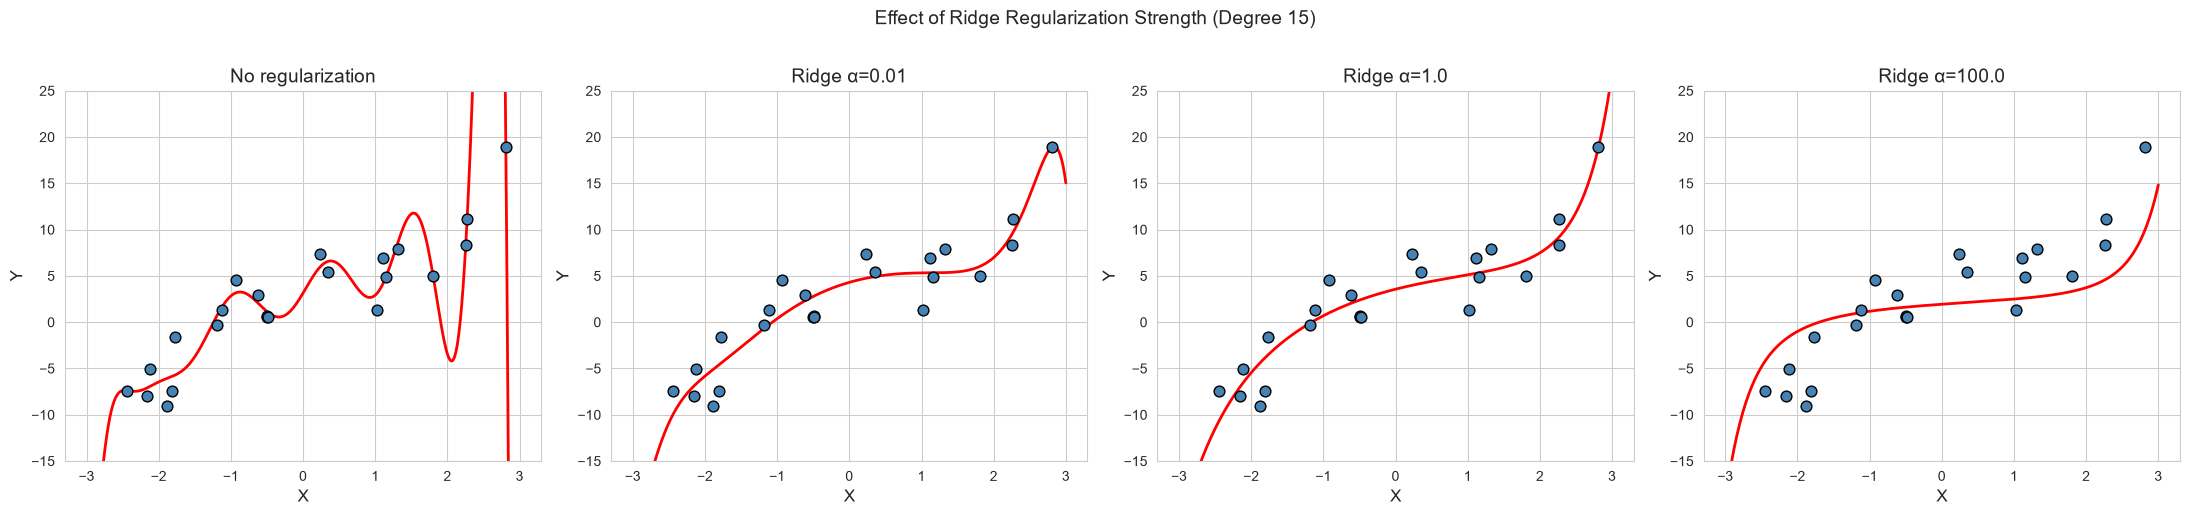

- α = 0     → no penalty, wild overfit
- α = 0.01  → mild smoothing
- α = 1.0   → good balance
- α = 100   → too much smoothing, approaches a straight line


In [18]:
# Show how Ridge alpha affects the fit
alphas = [0, 0.01, 1.0, 100.0]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, alpha in zip(axes, alphas):
    if alpha == 0:
        pipe = make_pipeline(
            PolynomialFeatures(degree=15, include_bias=False),
            StandardScaler(),
            LinearRegression()
        )
        label = 'No regularization'
    else:
        pipe = make_pipeline(
            PolynomialFeatures(degree=15, include_bias=False),
            StandardScaler(),
            Ridge(alpha=alpha)
        )
        label = f'Ridge α={alpha}'

    pipe.fit(X_r_2d, y_r)
    y_fit = pipe.predict(x_plot)

    ax.scatter(X_r, y_r, s=60, color='steelblue', edgecolor='black', zorder=3)
    ax.plot(x_plot, y_fit, 'r-', linewidth=2)
    ax.set_title(label)
    ax.set_ylim(-15, 25)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Effect of Ridge Regularization Strength (Degree 15)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('- α = 0     → no penalty, wild overfit')
print('- α = 0.01  → mild smoothing')
print('- α = 1.0   → good balance')
print('- α = 100   → too much smoothing, approaches a straight line')

## Summary Table

### Polynomial Regression

| Concept | Formula / Note |
|---|---|
| Polynomial equation | $\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \dots + \theta_d x^d$ |
| Reduces to | Multiple linear regression on $[1, x, x^2, \ldots, x^d]$ |
| OLS solution | $\theta = (X_{\text{poly}}^T X_{\text{poly}})^{-1} X_{\text{poly}}^T y$ |
| Key hyperparameter | Degree $d$ |
| Underfits if | Degree too low |
| Overfits if | Degree too high |

### Pipelines

| Benefit | How |
|---|---|
| Correct transformations | Fit-then-transform applied automatically |
| No data leakage | Test set never used to fit transformers |
| Cleaner code | One `.fit()` / `.predict()` call |
| CV & GridSearch friendly | Pipeline behaves like a single estimator |
| Reproducibility | Save/load the entire preprocessing + model |

### Typical Polynomial Pipeline

```python
Pipeline([
    ('poly',   PolynomialFeatures(degree=d)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())   # or Ridge for regularization
])
```

---

### Key Takeaways

1. **Polynomial regression** fits curved data by adding $x^2, x^3, \ldots$ as new features.
2. Under the hood, it's just **multiple linear regression** on transformed features.
3. **Degree** is the critical hyperparameter — too low underfits, too high overfits.
4. Use **cross-validation** to pick the right degree.
5. **Pipelines** bundle preprocessing + model into one object — prevents leakage, cleaner code.
6. For multiple features, PolynomialFeatures generates **interaction terms** automatically.
7. **Regularization (Ridge/Lasso)** in the pipeline lets you safely use high-degree polynomials.

### Next Steps
- **Ridge, Lasso, ElasticNet** — different flavors of regularization
- **GridSearchCV** — automatically tune degree + regularization together
- **Spline regression / GAMs** — more flexible non-linear regression
- **Decision Trees / Random Forests / Gradient Boosting** — non-parametric alternatives